Uniform and inverse CDF sampling

In [1]:
import math
import random 
def sample_uniform(a,b):
    return a+(b-a) *random.random()

def sample_exponential_inverse_cdf(lam):
    u=random.random()
    return -math.log(u)/lam 

In [4]:

print("Uniform samples:", [round(sample_uniform(2, 5),4) for _ in range(5)])


print("Exponential samples:", [round(sample_exponential_inverse_cdf(1.5), 4) for _ in range(5)])

Uniform samples: [4.5683, 2.0026, 3.2759, 3.8917, 3.1714]
Exponential samples: [0.1479, 0.2774, 0.9087, 0.6562, 0.1382]


Rejection sampling

In [8]:
def rejection_sampling(target_pdf,proposal_sample,proposal_pdf,M):
    while True:
        x=proposal_sample()
        u = random.random()
        if u < target_pdf(x) / (M * proposal_pdf(x)):
            return x

In [9]:
def target_pdf(x):
    # Unnormalized standard normal, only on [-3, 3]
    return math.exp(-x * x / 2)

def proposal_sample():
    return random.uniform(-3, 3)

def proposal_pdf(x):
    # Uniform on [-3, 3] has density 1/6
    return 1.0 / 6.0

# M must satisfy p(x) <= M * q(x) for all x in [-3,3].
# max p(x) = 1 (at x=0), q = 1/6, so M >= 6.
M = 6.0

samples = [rejection_sampling(target_pdf, proposal_sample, proposal_pdf, M)
           for _ in range(10_000)]

print("Mean:", sum(samples) / len(samples))   # ~ 0
print("Var :", sum(x*x for x in samples)/len(samples))  # ~ 1

Mean: -0.0033348645196623478
Var : 0.969391150737075


Accepted: 10000
Rejected: 14150
Acceptance rate: 0.414   (theory = 1/M = 0.167)
Empirical mean: 0.0024   (theory = 0)
Empirical var : 0.9631   (theory = 1)


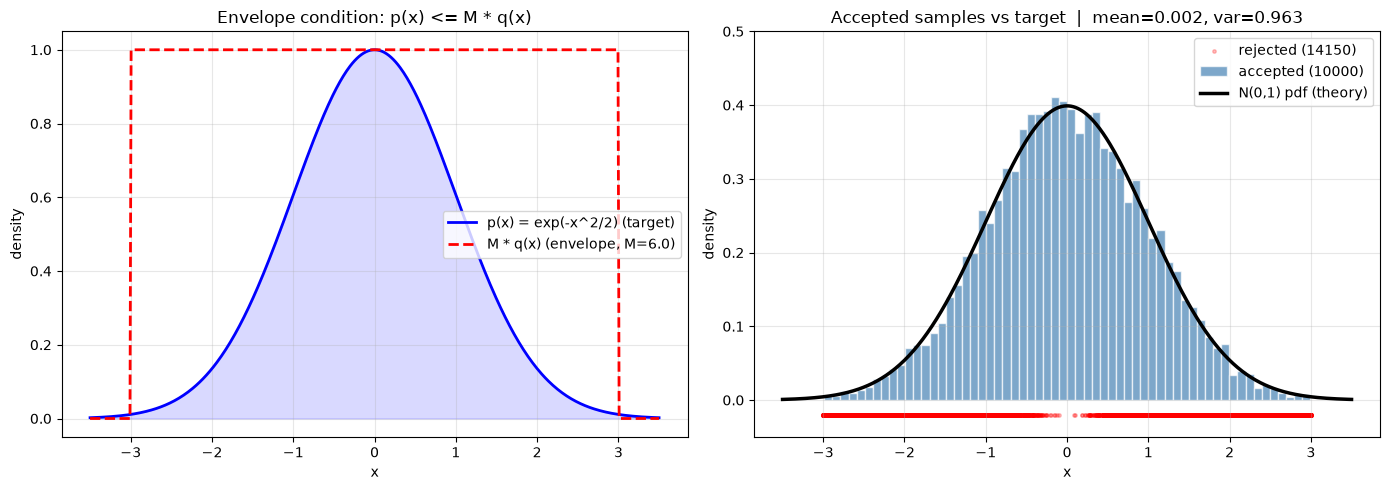

In [ ]:
import math
import random
import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = False   # ensure mathtext, not real LaTeX
import matplotlib.pyplot as plt

# ---------- Target: standard normal (unnormalized) ----------
def target_pdf(x):
    x = np.asarray(x, dtype=float)
    return np.exp(-x * x / 2)

# ---------- Proposal: Uniform on [-3, 3] ----------
def proposal_sample():
    return random.uniform(-3, 3)

def proposal_pdf(x):
    x = np.asarray(x, dtype=float)
    return np.where((x >= -3) & (x <= 3), 1.0 / 6.0, 0.0)

M = 6.0   # MUST be >= sup p(x)/q(x) = 6

# ---------- Rejection sampler with history ----------
def rejection_sampling_verbose(n_accept, target_pdf, proposal_sample, proposal_pdf, M):
    accepted, rejected = [], []
    while len(accepted) < n_accept:
        x = proposal_sample()
        u = random.random()
        p_x = float(target_pdf(x))
        q_x = float(proposal_pdf(x))
        if u < p_x / (M * q_x):
            accepted.append(x)
        else:
            rejected.append(x)
    return accepted, rejected

# ---------- Run ----------
random.seed(42)
N = 10_000
accepted, rejected = rejection_sampling_verbose(N, target_pdf, proposal_sample, proposal_pdf, M)

accepted = np.array(accepted)
rejected = np.array(rejected)

emp_mean = accepted.mean()
emp_var  = accepted.var()
acc_rate = N / (N + len(rejected))

print(f"Accepted: {N}")
print(f"Rejected: {len(rejected)}")
print(f"Acceptance rate: {acc_rate:.3f}   (theory = 1/M = {1/M:.3f})")
print(f"Empirical mean: {emp_mean:.4f}   (theory = 0)")
print(f"Empirical var : {emp_var:.4f}   (theory = 1)")

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ===== LEFT: Envelope =====
ax = axes[0]
xs = np.linspace(-3.5, 3.5, 500)
ax.plot(xs, target_pdf(xs), 'b-', lw=2, label='p(x) = exp(-x^2/2) (target)')
ax.plot(xs, M * proposal_pdf(xs), 'r--', lw=2, label=f'M * q(x) (envelope, M={M})')
ax.fill_between(xs, 0, target_pdf(xs), color='blue', alpha=0.15)
ax.set_title('Envelope condition: p(x) <= M * q(x)')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.legend(); ax.grid(alpha=0.3)

# ===== RIGHT: Histogram of accepted =====
ax = axes[1]
ax.scatter(rejected, np.full_like(rejected, -0.02),
           s=6, color='red', alpha=0.25, label=f'rejected ({len(rejected)})')
ax.hist(accepted, bins=60, density=True, color='steelblue',
        alpha=0.7, edgecolor='white', label=f'accepted ({len(accepted)})')

norm_const = math.sqrt(2 * math.pi)
ax.plot(xs, np.exp(-xs**2 / 2) / norm_const, 'k-', lw=2.5,
        label='N(0,1) pdf (theory)')

ax.set_title(f'Accepted samples vs target  |  mean={emp_mean:.3f}, var={emp_var:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_ylim(-0.05, 0.5)
ax.legend(loc='upper right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Importance sampling

In [14]:
def importance_sampling_estimate(f, target_pdf, proposal_pdf, proposal_sample, n):
    total = 0
    for _ in range(n):
        x = proposal_sample()
        w = target_pdf(x) / proposal_pdf(x)
        total += f(x) * w
    return total / n

In [15]:
def target_pdf(x):
    # Standard normal N(0,1)
    return math.exp(-x * x / 2) / math.sqrt(2 * math.pi)

def proposal_sample():
    # Uniform on [-3, 3]
    return random.uniform(-3, 3)

def proposal_pdf(x):
    if -3 <= x <= 3:
        return 1.0 / 6.0
    return 0.0

In [16]:
f = lambda x: x * x

In [17]:
random.seed(0)
n = 200_000
estimate = importance_sampling_estimate(f, target_pdf, proposal_pdf, proposal_sample, n)

print(f"Importance sampling estimate of E[X^2]: {estimate:.6f}")
print(f"True value (standard normal):           1.000000")

Importance sampling estimate of E[X^2]: 0.970634
True value (standard normal):           1.000000


Monte Carlo estimation of pi

In [18]:
def monte_carlo_pi(n):
    inside = 0
    for _ in range(n):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            inside += 1
    return 4 * inside / n

In [19]:
random.seed(0)
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    est = monte_carlo_pi(n)
    err = abs(est - math.pi)
    # 95% CI half-width: 1.96 * SE
    se = 4 * math.sqrt((math.pi/4) * (1 - math.pi/4) / n)
    print(f"n={n:>8}  π̂ = {est:.6f}  |error| = {err:.6f}  ±{1.96*se:.6f}")

n=     100  π̂ = 3.280000  |error| = 0.138407  ±0.321868
n=    1000  π̂ = 3.020000  |error| = 0.121593  ±0.101784
n=   10000  π̂ = 3.144800  |error| = 0.003207  ±0.032187
n=  100000  π̂ = 3.130560  |error| = 0.011033  ±0.010178
n= 1000000  π̂ = 3.141780  |error| = 0.000187  ±0.003219


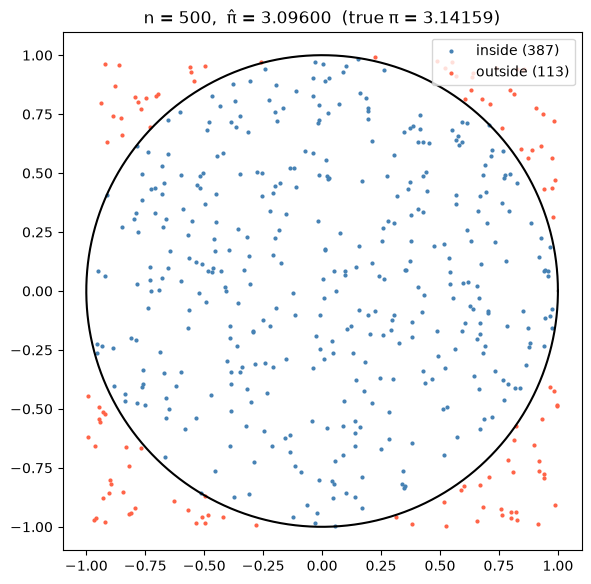

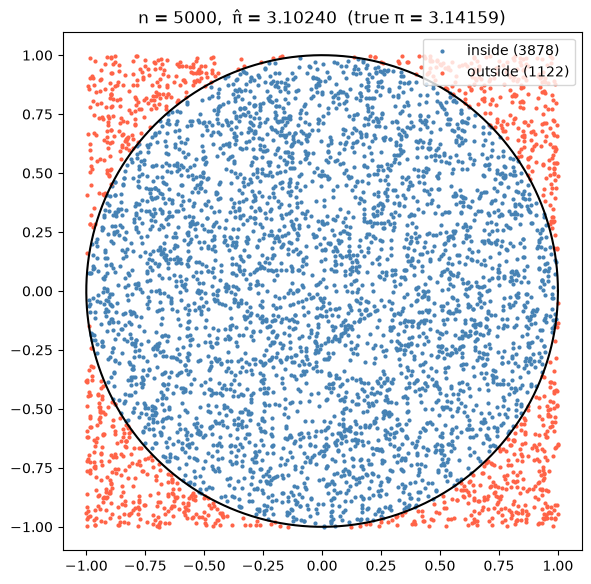

In [21]:
import matplotlib.pyplot as plt

def mc_pi_visual(n, seed=1):
    random.seed(seed)
    xs, ys, ins = [], [], []
    for _ in range(n):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        xs.append(x); ys.append(y)
        ins.append(x*x + y*y <= 1)
    xs = np.array(xs); ys = np.array(ys); ins = np.array(ins)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(xs[ins],  ys[ins],  s=4, color='steelblue', label=f'inside ({ins.sum()})')
    ax.scatter(xs[~ins], ys[~ins], s=4, color='tomato',    label=f'outside ({(~ins).sum()})')

    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=1.5)

    est = 4 * ins.mean()
    ax.set_aspect('equal')
    ax.set_title(f'n = {n},  π̂ = {est:.5f}  (true π = {math.pi:.5f})')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

mc_pi_visual(500)
mc_pi_visual(5000)

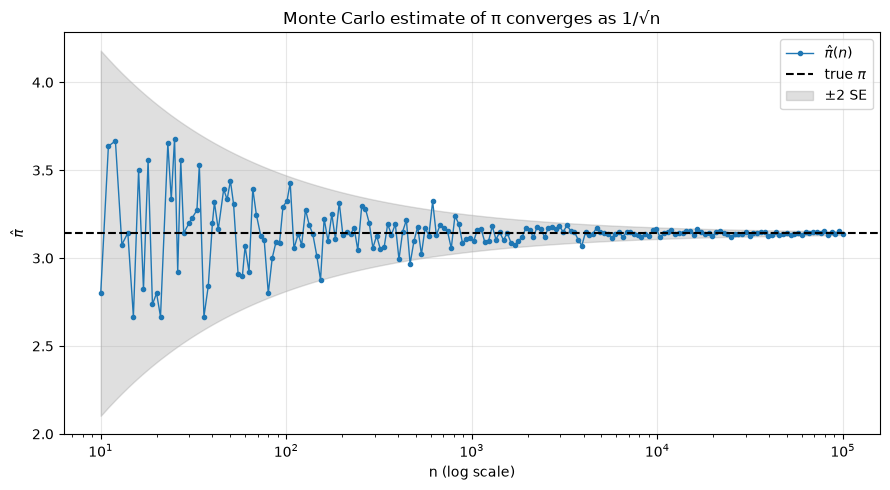

In [23]:
random.seed(42)
ns = np.unique(np.logspace(1, 5, 200).astype(int))
estimates = [monte_carlo_pi(n) for n in ns]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, estimates, 'o-', ms=3, lw=1, label=r'$\hat{\pi}(n)$')
ax.axhline(math.pi, color='k', ls='--', lw=1.5, label=r'true $\pi$')

# ±2 SE band
se = 4 * np.sqrt((math.pi/4)*(1 - math.pi/4) / ns)
ax.fill_between(ns, math.pi - 2*se, math.pi + 2*se,
                color='gray', alpha=0.25, label=r'$\pm 2$ SE')

ax.set_xscale('log')
ax.set_xlabel('n (log scale)')
ax.set_ylabel(r'$\hat{\pi}$')
ax.set_title('Monte Carlo estimate of π converges as 1/√n')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

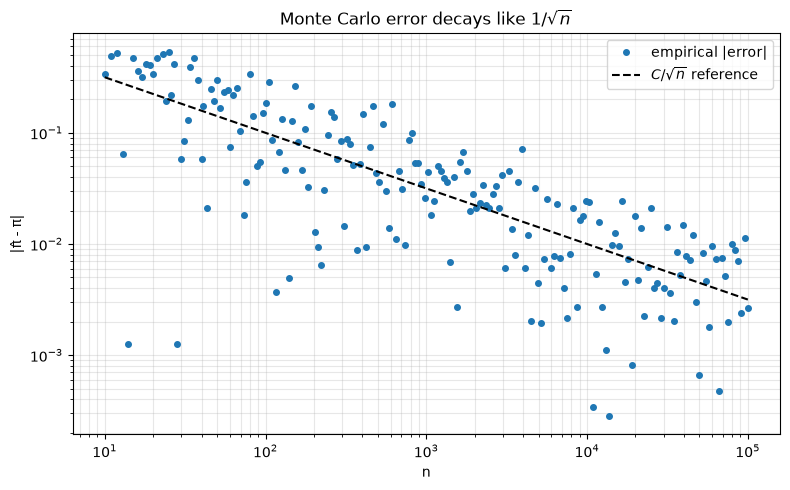

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
errors = np.abs(np.array(estimates) - math.pi)
ax.loglog(ns, errors, 'o', ms=4, label='empirical |error|')
ax.loglog(ns, 1.0/np.sqrt(ns), 'k--', label=r'$C/\sqrt{n}$ reference')

ax.set_xlabel('n')
ax.set_ylabel('|π̂ - π|')
ax.set_title('Monte Carlo error decays like $1/\\sqrt{n}$')
ax.legend(); ax.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Metropolis-Hastings MCMC

In [20]:
def metropolis_hastings(target_log_pdf, proposal_sample, proposal_log_pdf, x0, n_samples, burn_in):
    samples = []
    x = x0
    for i in range(n_samples + burn_in):
        x_new = proposal_sample(x)
        log_alpha = (target_log_pdf(x_new) + proposal_log_pdf(x, x_new)
                     - target_log_pdf(x) - proposal_log_pdf(x_new, x))
        if math.log(random.random()) < log_alpha:
            x = x_new
        if i >= burn_in:
            samples.append(x)
    return samples

Chain length: 30000
Empirical mean: 0.3501   (true = 0.0)
Empirical var : 9.8498   (true = 10.0000)
Fraction left of 0: 0.444   (true = 0.5)


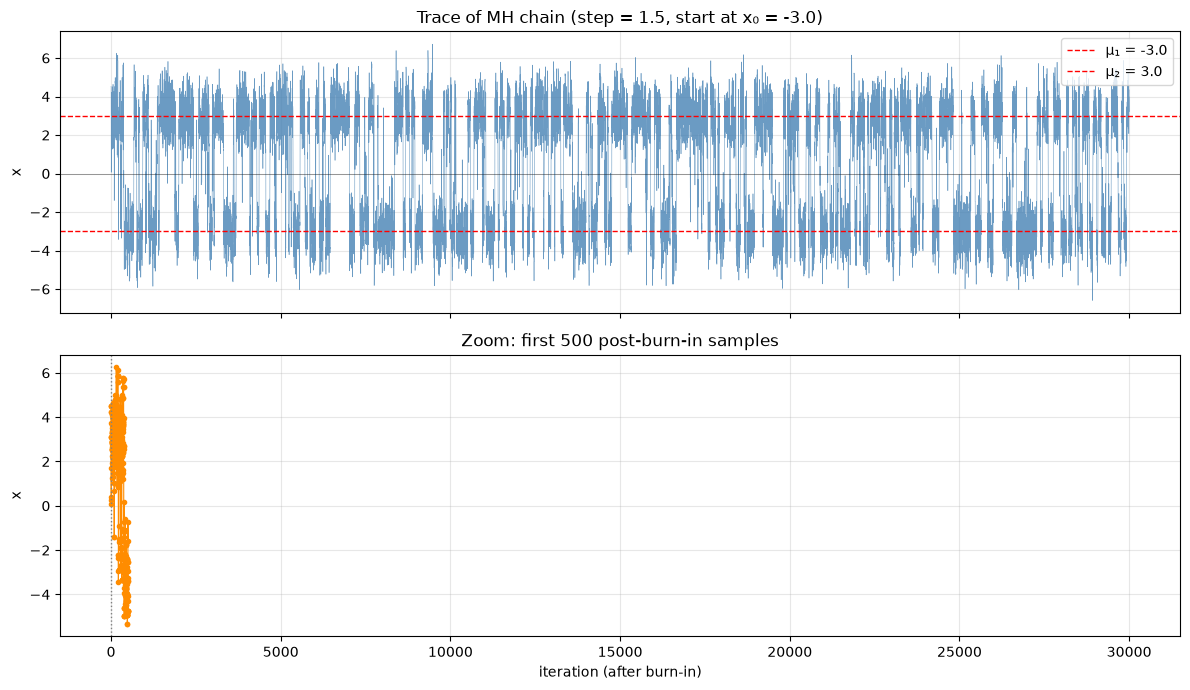

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# ---------- Your original MH function ----------
def metropolis_hastings(target_log_pdf, proposal_sample,
                        proposal_log_pdf, x0, n_samples, burn_in):
    samples = []
    x = x0
    for i in range(n_samples + burn_in):
        x_new = proposal_sample(x)
        log_alpha = (target_log_pdf(x_new) + proposal_log_pdf(x, x_new)
                     - target_log_pdf(x) - proposal_log_pdf(x_new, x))
        if math.log(random.random()) < log_alpha:
            x = x_new
        if i >= burn_in:
            samples.append(x)
    return samples

# ---------- Target: bimodal mixture of two Gaussians ----------
MU1, SIG1 = -3.0, 1.0
MU2, SIG2 =  3.0, 1.0

def log_normal(x, mu, sigma):
    return -0.5 * ((x - mu) / sigma) ** 2 - math.log(sigma * math.sqrt(2 * math.pi))

def log_sum_exp(a, b):
    if a < b:
        a, b = b, a
    return a + math.log1p(math.exp(b - a))

def target_log_pdf(x):
    # log of ( 0.5*N(mu1,sig1) + 0.5*N(mu2,sig2) )
    return log_sum_exp(log_normal(x, MU1, SIG1) + math.log(0.5),
                       log_normal(x, MU2, SIG2) + math.log(0.5))

# ---------- Proposal: Gaussian random walk ----------
STEP = 1.5   # proposal std dev

def proposal_sample(x):
    return random.gauss(x, STEP)

def proposal_log_pdf(x_new, x):
    # symmetric: q(x_new | x) = N(x_new; x, STEP^2)
    return -0.5 * ((x_new - x) / STEP) ** 2 - math.log(STEP * math.sqrt(2 * math.pi))

# ---------- Run MH ----------
random.seed(42)
x0 = -3.0             # start near the left mode
n_samples = 30_000
burn_in   = 2_000

chain = metropolis_hastings(target_log_pdf, proposal_sample,
                            proposal_log_pdf, x0, n_samples, burn_in)
chain = np.array(chain)

# ---------- Diagnostics ----------
print(f"Chain length: {len(chain)}")
print(f"Empirical mean: {chain.mean():.4f}   (true = {(MU1+MU2)/2:.1f})")
print(f"Empirical var : {chain.var():.4f}   (true = {SIG1**2 + ((MU1-MU2)/2)**2:.4f})")
print(f"Fraction left of 0: {(chain < 0).mean():.3f}   (true = 0.5)")

# ---------- Plot 1: Trace of the chain ----------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(chain, lw=0.4, color='steelblue', alpha=0.8)
ax.axhline(MU1, color='red', ls='--', lw=1, label=f'μ₁ = {MU1}')
ax.axhline(MU2, color='red', ls='--', lw=1, label=f'μ₂ = {MU2}')
ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.set_ylabel('x')
ax.set_title(f'Trace of MH chain (step = {STEP}, start at x₀ = {x0})')
ax.legend(); ax.grid(alpha=0.3)

# ---------- Plot 2: Zoomed-in first 500 steps (with burn-in) ----------
ax = axes[1]
zoom = 500
ax.plot(range(zoom), chain[:zoom], 'o-', ms=3, lw=0.8, color='darkorange')
ax.axvline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('iteration (after burn-in)')
ax.set_ylabel('x')
ax.set_title(f'Zoom: first {zoom} post-burn-in samples')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

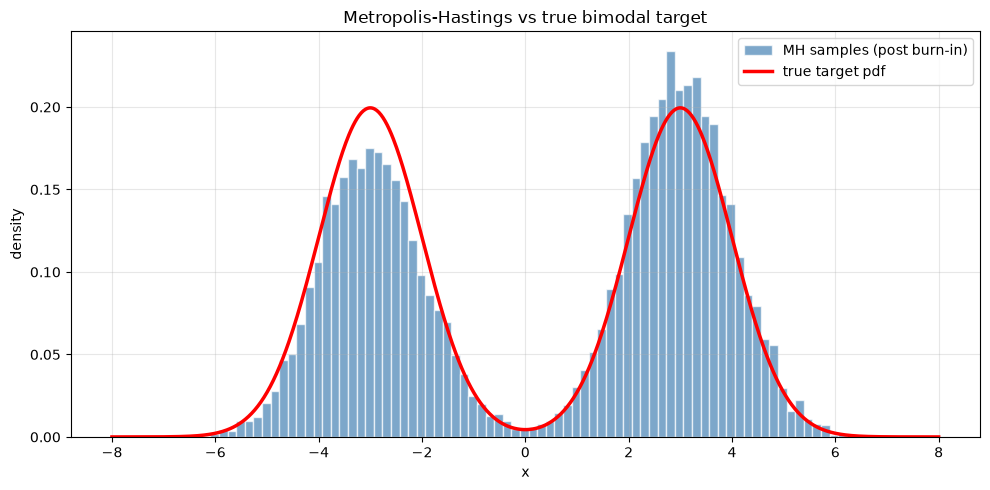

In [31]:
# ---------- Plot: Histogram of chain vs true PDF ----------
xs = np.linspace(-8, 8, 800)
true_pdf = np.array([
    0.5 * math.exp(log_normal(x, MU1, SIG1)) +
    0.5 * math.exp(log_normal(x, MU2, SIG2))
    for x in xs
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(chain, bins=80, density=True, color='steelblue',
        alpha=0.7, edgecolor='white', label='MH samples (post burn-in)')
ax.plot(xs, true_pdf, 'r-', lw=2.5, label='true target pdf')
ax.set_xlabel('x'); ax.set_ylabel('density')
ax.set_title('Metropolis-Hastings vs true bimodal target')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Gibbs sampling

In [32]:
def gibbs_sampling_2d(conditional_x_given_y, conditional_y_given_x, x0, y0, n_samples, burn_in):
    x, y = x0, y0
    samples = []
    for i in range(n_samples + burn_in):
        x = conditional_x_given_y(y)
        y = conditional_y_given_x(x)
        if i >= burn_in:
            samples.append((x, y))
    return samples

In [33]:
MU_X, MU_Y = 0.0, 0.0
SIG_X, SIG_Y = 1.0, 1.0
RHO = 0.85

In [34]:
def conditional_x_given_y(y):
    mean = MU_X + RHO * (SIG_X / SIG_Y) * (y - MU_Y)
    sd   = SIG_X * math.sqrt(1 - RHO**2)
    return random.gauss(mean, sd)

def conditional_y_given_x(x):
    mean = MU_Y + RHO * (SIG_Y / SIG_X) * (x - MU_X)
    sd   = SIG_Y * math.sqrt(1 - RHO**2)
    return random.gauss(mean, sd)

In [35]:
random.seed(42)
x0, y0 = -3.0, -3.0
n_samples = 20_000
burn_in   = 500

chain = gibbs_sampling_2d(conditional_x_given_y, conditional_y_given_x,
                          x0, y0, n_samples, burn_in)

chain = np.array(chain)   # shape (n_samples, 2)
xs, ys = chain[:, 0], chain[:, 1]

# ---------- Diagnostics ----------
print(f"Samples: {len(chain)}")
print(f"mean x = {xs.mean():+.3f},  true = {MU_X}")
print(f"mean y = {ys.mean():+.3f},  true = {MU_Y}")
print(f"var  x = {xs.var():.3f},  true = {SIG_X**2}")
print(f"var  y = {ys.var():.3f},  true = {SIG_Y**2}")
print(f"corr   = {np.corrcoef(xs, ys)[0,1]:.3f},  true = {RHO}")

Samples: 20000
mean x = -0.001,  true = 0.0
mean y = -0.000,  true = 0.0
var  x = 0.990,  true = 1.0
var  y = 0.991,  true = 1.0
corr   = 0.847,  true = 0.85


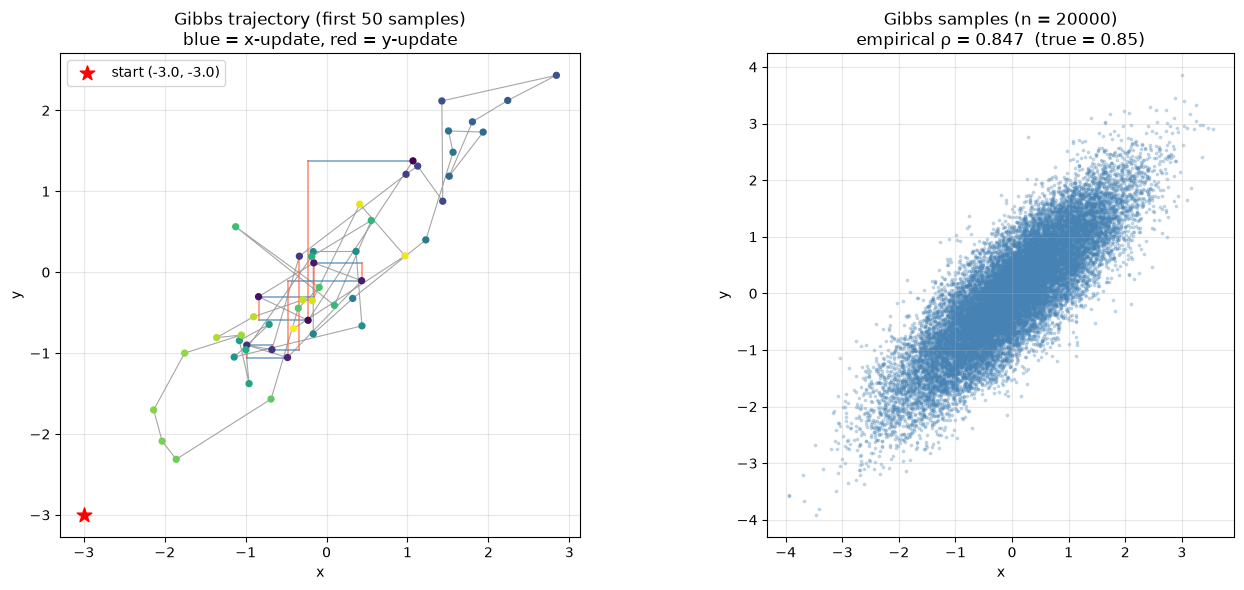

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- (a) Trajectory ----
ax = axes[0]
n_show = 50
ax.plot(xs[:n_show], ys[:n_show], '-', color='gray', lw=0.8, alpha=0.7)
ax.scatter(xs[:n_show], ys[:n_show], s=18, c=np.arange(n_show),
           cmap='viridis', zorder=3)
ax.scatter([x0], [y0], s=120, marker='*', color='red', zorder=4,
           label=f'start ({x0}, {y0})')

# Draw the horizontal/vertical move for the first few steps
for i in range(min(8, n_show - 1)):
    ax.plot([xs[i], xs[i+1]], [ys[i], ys[i]], color='steelblue', lw=1.2, alpha=0.7)
    ax.plot([xs[i+1], xs[i+1]], [ys[i], ys[i+1]], color='tomato', lw=1.2, alpha=0.7)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gibbs trajectory (first 50 samples)\n'
             'blue = x-update, red = y-update')
ax.legend(); ax.grid(alpha=0.3)
ax.set_aspect('equal')

# ---- (b) Scatter of many samples ----
ax = axes[1]
ax.scatter(xs, ys, s=3, alpha=0.25, color='steelblue')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Gibbs samples (n = {n_samples})\n'
             f'empirical ρ = {np.corrcoef(xs, ys)[0,1]:.3f}  (true = {RHO})')
ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

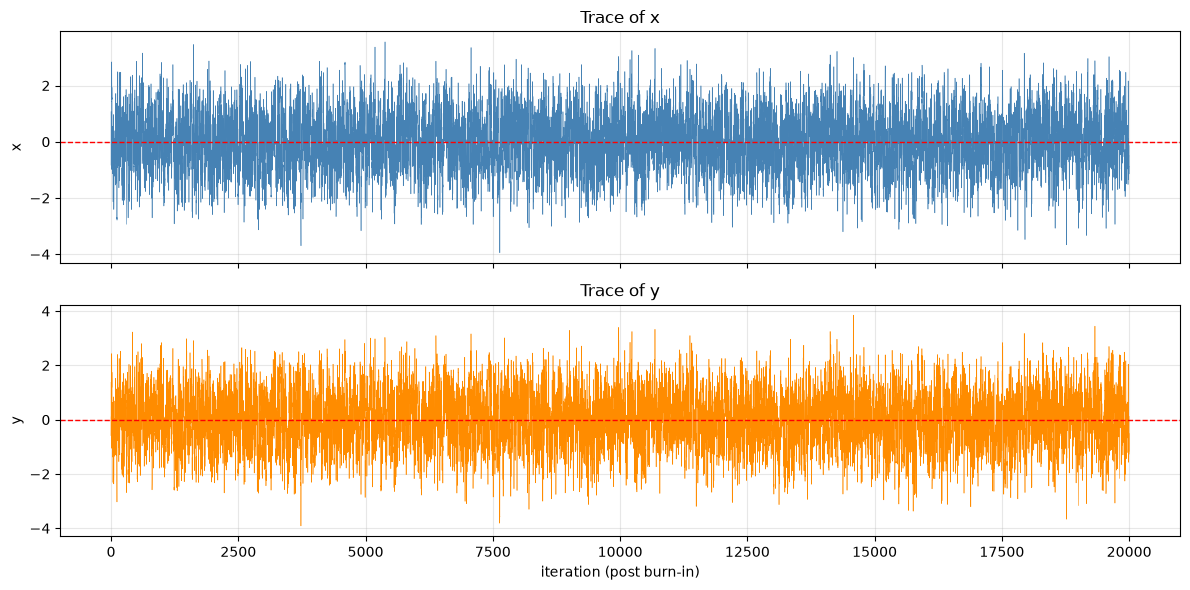

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(xs, lw=0.4, color='steelblue')
axes[0].axhline(MU_X, color='red', ls='--', lw=1)
axes[0].set_ylabel('x'); axes[0].set_title('Trace of x')
axes[0].grid(alpha=0.3)

axes[1].plot(ys, lw=0.4, color='darkorange')
axes[1].axhline(MU_Y, color='red', ls='--', lw=1)
axes[1].set_ylabel('y'); axes[1].set_xlabel('iteration (post burn-in)')
axes[1].set_title('Trace of y'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

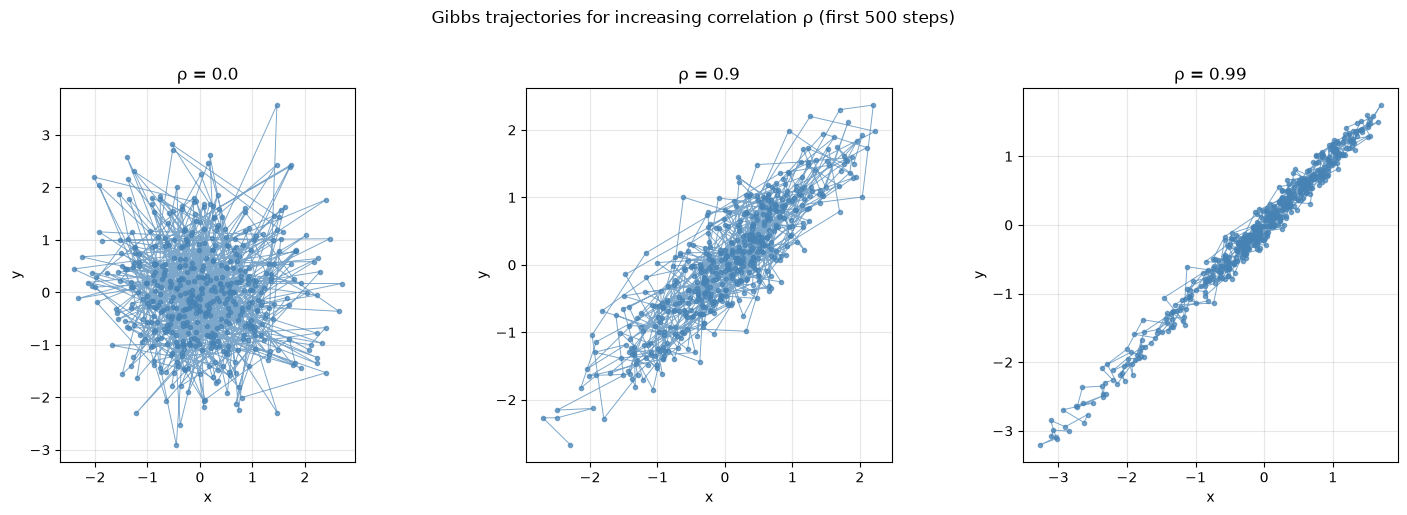

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rhos = [0.0, 0.9, 0.99]

for ax, rho in zip(axes, rhos):
    # re-define conditionals
    def cxg(y):
        return random.gauss(rho * y, math.sqrt(1 - rho**2))
    def cyg(x):
        return random.gauss(rho * x, math.sqrt(1 - rho**2))

    random.seed(0)
    chain = np.array(gibbs_sampling_2d(cxg, cyg, -3.0, -3.0, 500, 0))
    ax.plot(chain[:,0], chain[:,1], 'o-', ms=3, lw=0.7, color='steelblue',
            alpha=0.7)
    ax.set_title(f'ρ = {rho}')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Gibbs trajectories for increasing correlation ρ (first 500 steps)',
             y=1.02)
plt.tight_layout()
plt.show()

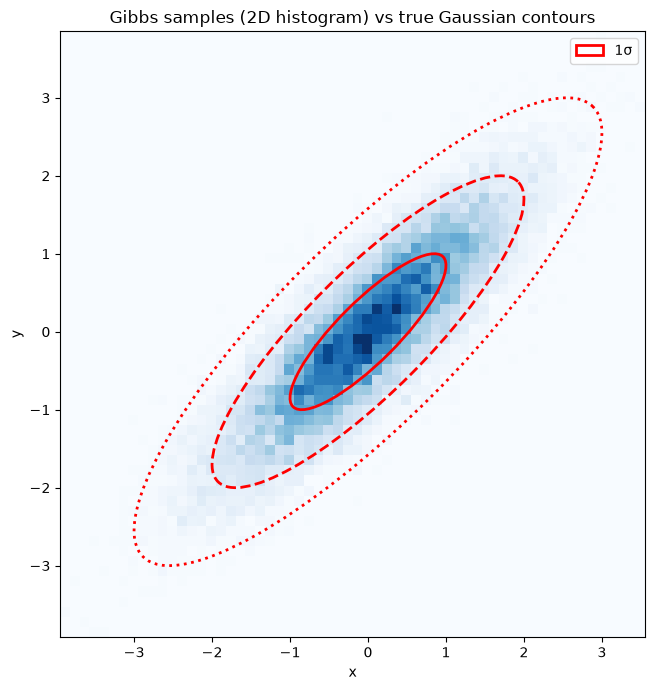

In [39]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(7, 7))
ax.hist2d(xs, ys, bins=60, cmap='Blues', density=True)

# Overlay the true 2D Gaussian via contour ellipses
cov = [[SIG_X**2, RHO*SIG_X*SIG_Y],
       [RHO*SIG_X*SIG_Y, SIG_Y**2]]
# 1σ, 2σ, 3σ contours of a 2D Gaussian
for k, style in zip([1, 2, 3], ['-', '--', ':']):
    eigval, eigvec = np.linalg.eigh(np.array(cov))
    angle = np.degrees(np.arctan2(eigvec[1, 0], eigvec[0, 0]))
    width, height = 2*k*np.sqrt(eigval[0]), 2*k*np.sqrt(eigval[1])
    e = Ellipse(xy=(MU_X, MU_Y), width=width, height=height,
                angle=angle, edgecolor='red', facecolor='none',
                lw=2, ls=style, label=f'{k}σ' if k==1 else None)
    ax.add_patch(e)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Gibbs samples (2D histogram) vs true Gaussian contours')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

Temperature sampling

In [40]:
def softmax(logits):
    max_l = max(logits)
    exps = [math.exp(z - max_l) for z in logits]
    total = sum(exps)
    return [e / total for e in exps]

def temperature_sample(logits, temperature):
    scaled = [z / temperature for z in logits]
    probs = softmax(scaled)
    return sample_from_probs(probs)

In [41]:
def sample_from_probs(probs):
    r = random.random()
    cum = 0.0
    for i, p in enumerate(probs):
        cum += p
        if r < cum:
            return i
    return len(probs) - 1   # numerical safety

In [42]:
tokens = ["the", "cat", "sat", "on", "a", "mat", "dog", "ran"]
logits = [3.2, 2.8, 1.5, 1.0, 0.5, 0.2, -0.5, -1.5]


In [46]:
print(f"{'Token':<6} {'logit':>7} | " +
      "  ".join(f"T={T:<4}" for T in [0.1, 0.5, 1.0, 2.0, 5.0]))
print("-" * 70)

dist_table = {}
for T in [0.1, 0.5, 1.0, 2.0, 5.0]:
    scaled = [z / T for z in logits]
    dist_table[T] = softmax(scaled)

for i, tok in enumerate(tokens):
    row = f"{tok:<6} {logits[i]:>7.2f} | "
    row += "  ".join(f"{dist_table[T][i]:.4f}" for T in [0.1, 0.5, 1.0, 2.0, 5.0])
    print(row)

Token    logit | T=0.1   T=0.5   T=1.0   T=2.0   T=5.0 
----------------------------------------------------------------------
the       3.20 | 0.9820  0.6655  0.4729  0.3018  0.1895
cat       2.80 | 0.0180  0.2990  0.3170  0.2471  0.1749
sat       1.50 | 0.0000  0.0222  0.0864  0.1290  0.1349
on        1.00 | 0.0000  0.0082  0.0524  0.1004  0.1220
a         0.50 | 0.0000  0.0030  0.0318  0.0782  0.1104
mat       0.20 | 0.0000  0.0016  0.0235  0.0673  0.1040
dog      -0.50 | 0.0000  0.0004  0.0117  0.0474  0.0904
ran      -1.50 | 0.0000  0.0001  0.0043  0.0288  0.0740


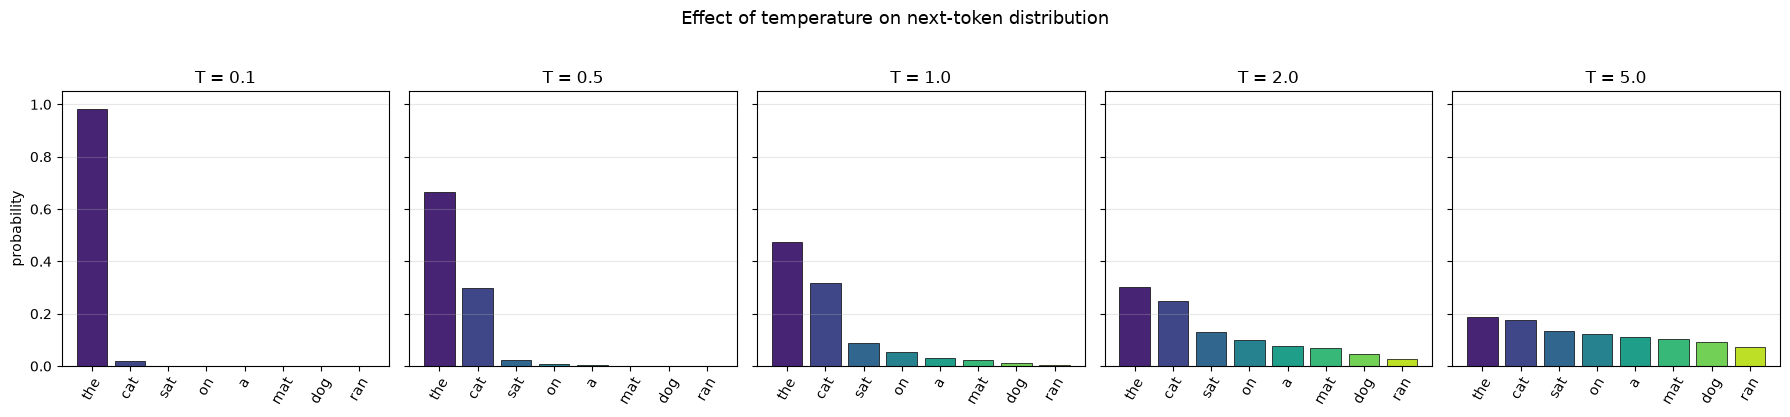

In [47]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

temps = [0.1, 0.5, 1.0, 2.0, 5.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(tokens)))

for ax, T in zip(axes, temps):
    scaled = [z / T for z in logits]
    probs = softmax(scaled)
    bars = ax.bar(tokens, probs, color=colors, edgecolor='black', lw=0.5)
    ax.set_title(f'T = {T}')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=60)
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel('probability')
plt.suptitle('Effect of temperature on next-token distribution', y=1.03, fontsize=13)
plt.tight_layout()

plt.show()

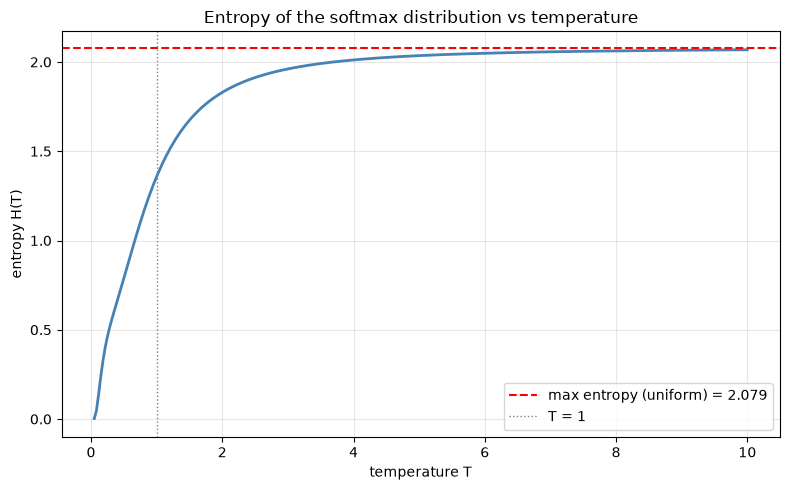

In [48]:
def entropy(probs):
    return -sum(p * math.log(p) for p in probs if p > 0)

Ts = np.linspace(0.05, 10.0, 300)
H_vals = [entropy(softmax([z / T for z in logits])) for T in Ts]
H_max  = math.log(len(logits))   # entropy of uniform

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Ts, H_vals, lw=2, color='steelblue')
ax.axhline(H_max, color='red', ls='--', lw=1.5,
           label=f'max entropy (uniform) = {H_max:.3f}')
ax.axvline(1.0, color='gray', ls=':', lw=1, label='T = 1')
ax.set_xlabel('temperature T')
ax.set_ylabel('entropy H(T)')
ax.set_title('Entropy of the softmax distribution vs temperature')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

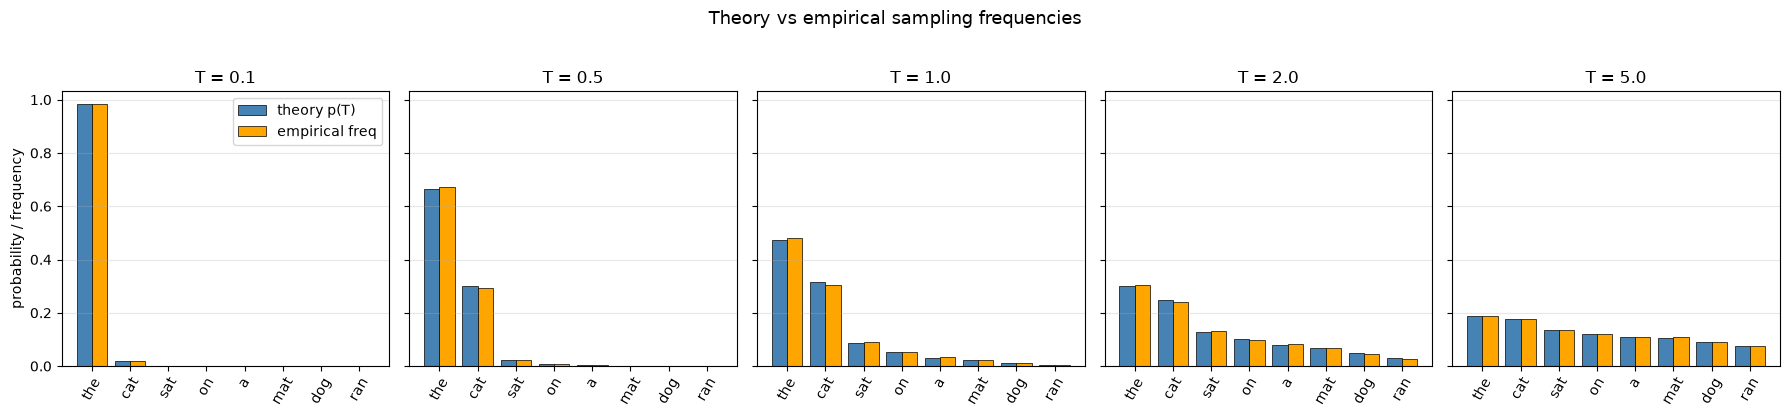

In [49]:
random.seed(0)
n_draws = 20_000
temps = [0.1, 0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for ax, T in zip(axes, temps):
    probs = softmax([z / T for z in logits])
    counts = [0] * len(logits)
    for _ in range(n_draws):
        i = temperature_sample(logits, T)
        counts[i] += 1
    freq = [c / n_draws for c in counts]

    x = np.arange(len(tokens))
    ax.bar(x - 0.2, probs, width=0.4, color='steelblue',
           label='theory p(T)', edgecolor='black', lw=0.5)
    ax.bar(x + 0.2, freq, width=0.4, color='orange',
           label='empirical freq', edgecolor='black', lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(tokens, rotation=60)
    ax.set_title(f'T = {T}')
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel('probability / frequency')
axes[0].legend()
plt.suptitle('Theory vs empirical sampling frequencies', y=1.03, fontsize=13)
plt.tight_layout()

plt.show()

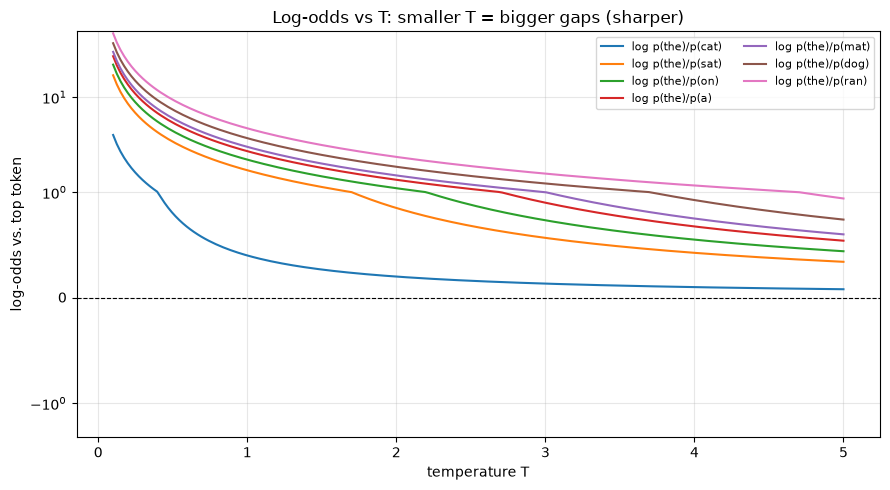

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

Ts = np.linspace(0.1, 5.0, 200)
top = 0   # the argmax token
for j in range(1, len(tokens)):
    log_odds = [(logits[top] - logits[j]) / T for T in Ts]
    ax.plot(Ts, log_odds, label=f'log p(the)/p({tokens[j]})')

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('temperature T')
ax.set_ylabel('log-odds vs. top token')
ax.set_yscale('symlog', linthresh=1)
ax.set_title('Log-odds vs T: smaller T = bigger gaps (sharper)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()